## Machine Learning Workshop - Crewes 2020: Convolution Neural Networks Explained
In this lab we will look at how Convolutional Neural Networks for classification. \
Based on Chapter 14 from Aurelien Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow.\
and Chapter 5 on Fracois Chollet's book, Deep Learning with Python.
Original code examples from book in github [here](https://github.com/ageron/handson-ml2)

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/CNN_Explained.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
    IS_COLAB = True
except Exception:
    IS_COLAB = False

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"
if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. CNNs can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware accelerator.")

# Add for GPU BEFORE JSON
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config = ConfigProto()
config.gpu_options.allow_growth = True
session = InteractiveSession(config=config)
####################################

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)
tf.random.set_seed(42)

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

## Example 1: Fully Connected (Dense) Network vs Convolutional Neural Network.
Compare a Fully Connected Network (FCN) with a Convolution Neural Network (CNN) for the same dataset.

### Loading data 
We will load the MNIST dataset (description [here](https://en.wikipedia.org/wiki/MNIST_database))\
Also, we will normalize the pixel values by substracting the mean and dividing by the standard deviatio.\
Finally we will separate into the train, validation and testing datasets.\
To treat each digit as an image, we need to add the feature axis, 1 in this case because it is black-white image.

In [2]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

X_mean = X_train.mean(axis=0, keepdims=True)
X_std = X_train.std(axis=0, keepdims=True) + 1e-7
X_train = (X_train - X_mean) / X_std
X_valid = (X_valid - X_mean) / X_std
X_test = (X_test - X_mean) / X_std

X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [6]:
#Let us see the array sizes
print('X_train ',X_train.shape)
print('X_valid ',X_valid.shape)
print('X_test  ',X_test.shape)

X_train  (55000, 28, 28, 1)
X_valid  (5000, 28, 28, 1)
X_test   (10000, 28, 28, 1)


### Fully Connected Layer.
For comparison, we will first create a FCN (not the ideal for computer vision)\
These networks do not have translational invariance and therefore need different filters for the same patterns at different locations. \
FCN assume the input has the shape (nbatches, nelements) (2 dimensions) so we need to flatten the images first. 

In [7]:
model1d = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal",activation="relu"),
    keras.layers.Dense(100, kernel_initializer="he_normal",activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])
model1d.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])

In [8]:
model1d.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 300)               235500    
_________________________________________________________________
dense_1 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [9]:
history1d=model1d.fit(X_train[:,:,:,0],y_train,epochs=10,validation_data=(X_valid[:,:,:,0],y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 71us/sample - loss: 1.2254 - accuracy: 0.6508 - val_loss: 0.5774 - val_accuracy: 0.8642
Epoch 2/10
55000/55000 [==============================] - 3s 55us/sample - loss: 0.5278 - accuracy: 0.8583 - val_loss: 0.3695 - val_accuracy: 0.9106
Epoch 3/10
55000/55000 [==============================] - 3s 55us/sample - loss: 0.3936 - accuracy: 0.8895 - val_loss: 0.2987 - val_accuracy: 0.9248
Epoch 4/10
55000/55000 [==============================] - 3s 56us/sample - loss: 0.3322 - accuracy: 0.9045 - val_loss: 0.2623 - val_accuracy: 0.9318
Epoch 5/10
55000/55000 [==============================] - 3s 56us/sample - loss: 0.2948 - accuracy: 0.9146 - val_loss: 0.2382 - val_accuracy: 0.9364
Epoch 6/10
55000/55000 [==============================] - 3s 56us/sample - loss: 0.2685 - accuracy: 0.9221 - val_loss: 0.2224 - val_accuracy: 0.9414
Epoch 7/10
55000/55000 [==============================] -

In [10]:
#Let us see the mean square error (MSE)
MSE_DN=model1d.evaluate(X_test[:,:,:,0],y_test)
print("MSE for FCC = ", MSE_DN)

10000/10000 [==============================] - 0s 48us/sample - loss: 127.4879 - accuracy: 0.9365
MSE for FCC =  [127.48794192893357, 0.9365]


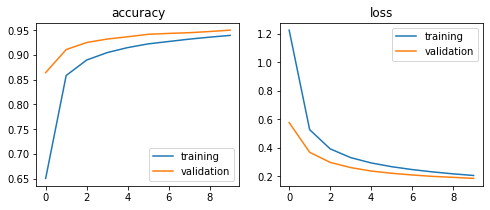

In [11]:
plt.figure(figsize=(8,3))
plt.subplot(121),plt.plot(history1d.history['accuracy'],label='training');plt.plot(history1d.history['val_accuracy'],label='validation');plt.title('accuracy')
plt.legend()
plt.subplot(122),plt.plot(history1d.history['loss'],label='training');plt.plot(history1d.history['val_loss'],label='validation');plt.title('loss')
plt.legend();

### Convolutional Network
We start by taking the images (1 channel) and creating 32 feature maps. \
Then we reduce the image size by 2 and double the channels.\
Repeat until we get to the desired image size (3x3) nad map to a dense layer to finish the classification

In [14]:
from tensorflow.keras import layers
from tensorflow.keras import models

model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [15]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_3 (Conv2D)            (None, 26, 26, 32)        320       
_________________________________________________________________
max_pooling2d_3 (MaxPooling2 (None, 13, 13, 32)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 11, 11, 64)        18496     
_________________________________________________________________
max_pooling2d_4 (MaxPooling2 (None, 5, 5, 64)          0         
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 3, 3, 64)          36928     
_________________________________________________________________
flatten_2 (Flatten)          (None, 576)               0         
_________________________________________________________________
dense_6 (Dense)              (None, 64)               

In [19]:
model.compile(optimizer='rmsprop',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [20]:
history=model.fit(X_train,y_train,epochs=10,validation_data=(X_valid,y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 7s 130us/sample - loss: 0.1288 - accuracy: 0.9604 - val_loss: 0.0376 - val_accuracy: 0.9902
Epoch 2/10
55000/55000 [==============================] - 5s 91us/sample - loss: 0.0451 - accuracy: 0.9865 - val_loss: 0.0437 - val_accuracy: 0.9904
Epoch 3/10
55000/55000 [==============================] - 5s 91us/sample - loss: 0.0341 - accuracy: 0.9906 - val_loss: 0.0518 - val_accuracy: 0.9906
Epoch 4/10
55000/55000 [==============================] - 5s 88us/sample - loss: 0.0282 - accuracy: 0.9921 - val_loss: 0.0533 - val_accuracy: 0.9896
Epoch 5/10
55000/55000 [==============================] - 5s 90us/sample - loss: 0.0236 - accuracy: 0.9933 - val_loss: 0.0687 - val_accuracy: 0.9884
Epoch 6/10
55000/55000 [==============================] - 5s 89us/sample - loss: 0.0192 - accuracy: 0.9950 - val_loss: 0.0718 - val_accuracy: 0.9906
Epoch 7/10
55000/55000 [==============================] 

In [21]:
model.evaluate(X_test,y_test)

10000/10000 [==============================] - 1s 57us/sample - loss: 5546.5327 - accuracy: 0.9916


[5546.5326611869295, 0.9916]

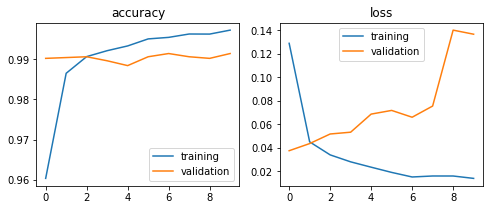

In [22]:
plt.figure(figsize=(8,3))
plt.subplot(121),plt.plot(history.history['accuracy'],label='training');plt.plot(history.history['val_accuracy'],label='validation');plt.title('accuracy')
plt.legend()
plt.subplot(122),plt.plot(history.history['loss'],label='training');plt.plot(history.history['val_loss'],label='validation');plt.title('loss')
plt.legend()

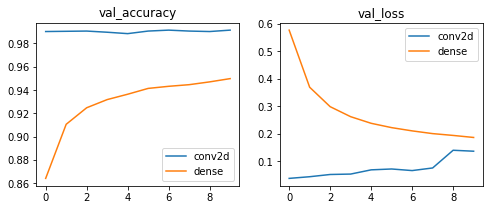

In [23]:
plt.figure(figsize=(8,3))
plt.subplot(121),plt.plot(history.history['val_accuracy'],label='conv2d');plt.plot(history1d.history['val_accuracy'],label='dense');plt.title('val_accuracy')
plt.legend()
plt.subplot(122),plt.plot(history.history['val_loss'],label='conv2d');plt.plot(history1d.history['val_loss'],label='dense');plt.title('val_loss')
plt.legend()

In [12]:
model=keras.models.Sequential([
    keras.layers.Conv2D(64, kernel_size=(7,7), activation='relu', padding='SAME',input_shape=[28,28,1]),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(128, kernel_size=(5,5), activation='relu', padding='SAME'),
    keras.layers.MaxPooling2D(),
    keras.layers.Conv2D(256, kernel_size=(3,3), activation='relu', padding='SAME'),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(10, activation='softmax')    
])